Taken the refrence from - https://towardsdatascience.com/loading-custom-image-dataset-for-deep-learning-models-part-1-d64fa7aaeca6

In [1]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
import cv2
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from  matplotlib import pyplot as plt
import matplotlib.image as mpimg
import seaborn as sn
%matplotlib inline

In [2]:
IMG_WIDTH=28 # img size
IMG_HEIGHT=28
train_img_folder=r'/content/drive/MyDrive/Colab Notebooks/GurNum/train'
test_img_folder=r'/content/drive/MyDrive/Colab Notebooks/GurNum/val'

In [3]:
# This fun, reading the image from folder and the labels and preprating trin/test data
def create_dataset(img_folder):
   
    img_data_array=[]
    class_name=[]
   
    for dir1 in os.listdir(img_folder):
        for file in os.listdir(os.path.join(img_folder, dir1)):
       
            image_path= os.path.join(img_folder, dir1,  file)
            image= cv2.imread( image_path, cv2.COLOR_BGR2RGB)
            image=cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH),interpolation = cv2.INTER_AREA)
            image=np.array(image)
            image = image.astype('float32')
            image /= 255 
            img_data_array.append(image)
            class_name.append(dir1)
    return img_data_array, class_name# extract the image array and class name
train_images, train_labels =create_dataset(train_img_folder)
test_images, test_labels =create_dataset(test_img_folder)

In [4]:
print(len(train_images))
print(len(train_images[0]))

1000
28


In [5]:
# Define the neural network model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Flatten the input
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons (one for each digit) and softmax activation
])

# Compile the model with categorical cross-entropy loss and Adam optimizer
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model on the training data
model.fit(x=np.array(train_images, np.float32), y=np.array(train_labels, np.float32), epochs=10)

# Evaluate the model on the test data
test_loss, test_acc = model.evaluate(x=np.array(test_images, np.float32), y=np.array(test_labels, np.float32))
print('Test accuracy:', test_acc)

Epoch 1/10
32/32 [==============================] - 1s 4ms/step - loss: 1.1223 - accuracy: 0.6780
Epoch 2/10
32/32 [==============================] - 0s 4ms/step - loss: 0.3046 - accuracy: 0.9250
Epoch 3/10
32/32 [==============================] - 0s 4ms/step - loss: 0.1913 - accuracy: 0.9510
Epoch 4/10
32/32 [==============================] - 0s 3ms/step - loss: 0.1387 - accuracy: 0.9680
Epoch 5/10
32/32 [==============================] - 0s 4ms/step - loss: 0.1156 - accuracy: 0.9710
Epoch 6/10
32/32 [==============================] - 0s 3ms/step - loss: 0.0875 - accuracy: 0.9820
Epoch 7/10
32/32 [==============================] - 0s 4ms/step - loss: 0.0771 - accuracy: 0.9860
Epoch 8/10
32/32 [==============================] - 0s 3ms/step - loss: 0.0637 - accuracy: 0.9870
Epoch 9/10
32/32 [==============================] - 0s 4ms/step - loss: 0.0486 - accuracy: 0.9970
Epoch 10/10
6/6 [==============================] - 0s 3ms/step - loss: 0.1671 - accuracy: 0.9607
Test accuracy: 0.9606

In [6]:
y_predicted = model.predict(x=np.array(test_images, np.float32))
y_predicted_labels=[np.argmax(i) for i in y_predicted]

6/6 [==============================] - 0s 2ms/step


In [7]:
# confusion matrix to validate our model
cm = tf.math.confusion_matrix(labels=np.array(test_labels, np.float32), predictions=y_predicted_labels)

Text(95.72222222222221, 0.5, 'Actual')

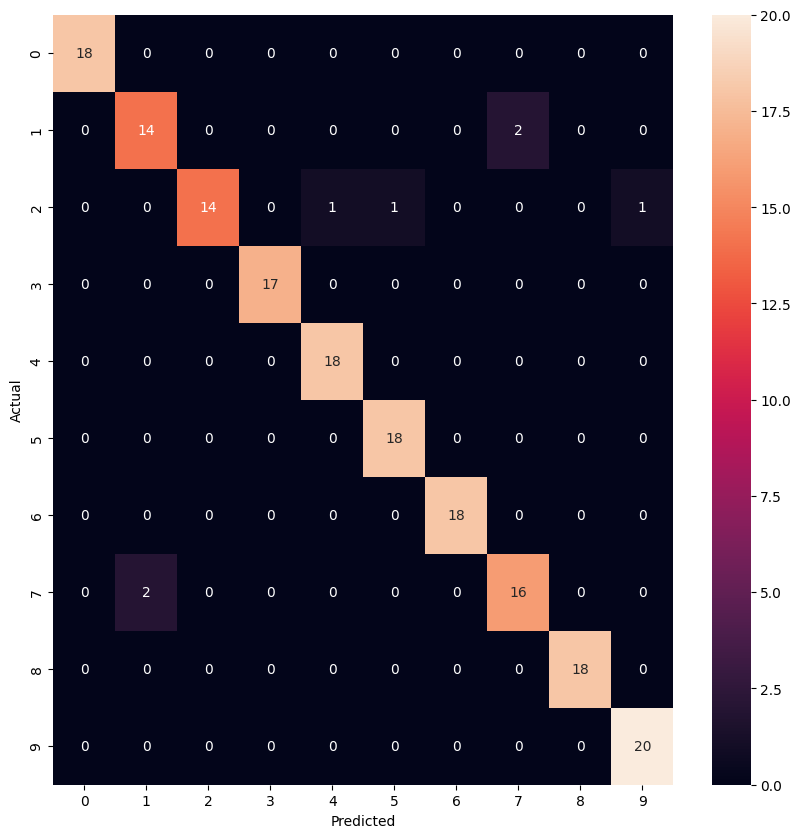

In [8]:
plt.figure(figsize = (10,10))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')